# Final Combined Amazon Review Notebook

This notebook is the single entry point for the project. It combines:

1. **Final sentiment-model results** for the main trained model  
2. **Low-credibility / suspicious review scoring** using the combined credibility model  
3. **Graphs and summary tables**  
4. **Example reviews** from the suspicious and not-suspicious groups  

Use this notebook for both your final presentation and for testing a new processed dataset.


In [25]:

# =========================
# Main settings
# =========================

# Final result files from the main training pipeline
FINAL_RESULTS_CSV = r"dataset\best_single_model_nn_results.csv"
FINAL_REPORT_CSV = r"dataset\best_single_model_nn_classification_report.csv"
FINAL_CONFUSION_CSV = r"dataset\best_single_model_nn_confusion_matrix.csv"

# Combined credibility model
COMBINED_MODEL_PATH = r"dataset\combined_review_credibility_model.joblib"

# Processed dataset to test
TEST_DATASET_PATH = r"dataset\new_amazon_test_ready.csv"

# Optional: save scored outputs from this notebook run
SAVE_SCORED_OUTPUT = True
SCORED_OUTPUT_CSV = r"dataset\notebook_scored_reviews.csv"
SUMMARY_OUTPUT_CSV = r"dataset\notebook_scored_summary.csv"

# Example display settings
NUM_SUSPICIOUS_EXAMPLES = 10
NUM_NOT_SUSPICIOUS_EXAMPLES = 10
TEXT_COL = "text"
CLEAN_TEXT_COL = "clean_text"
CATEGORY_COL = "category"
TRUE_SENTIMENT_COL = "sentiment"


In [26]:

import os
import sys
import json
import types
import warnings
from collections import Counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# -------------------------
# Compatibility helper
# -------------------------
# The saved sentiment bundle was created with a custom transformer stored under __main__.
# Register the same class here before joblib.load(...) so the bundle can be loaded safely.

class TextStatsTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        series = pd.Series(X).fillna("").astype(str)

        char_len = series.str.len().astype(float)
        word_count = series.str.split().str.len().astype(float)
        exclam_count = series.str.count("!").astype(float)
        question_count = series.str.count(r"\?").astype(float)

        token_lists = series.str.split()
        unique_ratio = []
        avg_word_len = []
        digit_ratio = []
        uppercase_ratio = []

        for text, tokens in zip(series.tolist(), token_lists.tolist()):
            if tokens:
                unique_ratio.append(len(set(tokens)) / len(tokens))
                avg_word_len.append(sum(len(t) for t in tokens) / len(tokens))
            else:
                unique_ratio.append(0.0)
                avg_word_len.append(0.0)

            if text:
                digit_ratio.append(sum(ch.isdigit() for ch in text) / len(text))
                letters = [ch for ch in text if ch.isalpha()]
                if letters:
                    uppercase_ratio.append(sum(ch.isupper() for ch in letters) / len(letters))
                else:
                    uppercase_ratio.append(0.0)
            else:
                digit_ratio.append(0.0)
                uppercase_ratio.append(0.0)

        arr = np.column_stack(
            [
                char_len.to_numpy(),
                word_count.to_numpy(),
                exclam_count.to_numpy(),
                question_count.to_numpy(),
                np.asarray(unique_ratio, dtype=float),
                np.asarray(avg_word_len, dtype=float),
                np.asarray(digit_ratio, dtype=float),
                np.asarray(uppercase_ratio, dtype=float),
            ]
        )
        return sparse.csr_matrix(arr)

# Register under __main__ for old pickle compatibility
import __main__
__main__.TextStatsTransformer = TextStatsTransformer

pd.set_option("display.max_colwidth", 300)


## 1) Final sentiment-model results

In [27]:

def safe_read_csv(path):
    if os.path.exists(path):
        return pd.read_csv(path, low_memory=False)
    return None

results_df = safe_read_csv(FINAL_RESULTS_CSV)
report_df = safe_read_csv(FINAL_REPORT_CSV)
conf_df = safe_read_csv(FINAL_CONFUSION_CSV)

if results_df is None:
    print(f"Result file not found: {FINAL_RESULTS_CSV}")
    print("If your final result CSV uses a different name, update the settings cell.")
else:
    print("Loaded final result summary:")
    display(results_df)

if report_df is not None:
    print("Loaded classification report:")
    display(report_df)

if conf_df is not None:
    print("Loaded confusion matrix:")
    display(conf_df)


Loaded final result summary:


,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,config_json
0,validation,0.919333,0.799596,0.704332,0.740658,0.910197,0.919333,0.911969,"{""word_max_features"": 70000, ""char_max_features"": 50000, ""word_ngram_range"": [1, 2], ""char_ngram_range"": [2, 5], ""word_min_df"": 2, ""char_min_df"": 2, ""c_value"": 0.35, ""neutral_weight"": 1.55, ""negative_weight"": 1.05, ""positive_weight"": 0.88, ""use_text_stats"": true, ""max_iter"": 9000}"
1,test,0.917556,0.792792,0.698067,0.735188,0.907910,0.917556,0.910145,"{""word_max_features"": 70000, ""char_max_features"": 50000, ""word_ngram_range"": [1, 2], ""char_ngram_range"": [2, 5], ""word_min_df"": 2, ""char_min_df"": 2, ""c_value"": 0.35, ""neutral_weight"": 1.55, ""negative_weight"": 1.05, ""positive_weight"": 0.88, ""use_text_stats"": true, ""max_iter"": 9000}"


Loaded classification report:


,label,precision,recall,f1-score,support
0,negative,0.799419,0.714750,0.754717,1539.000000
1,neutral,0.636700,0.396472,0.488658,1304.000000
2,positive,0.942259,0.982978,0.962188,15157.000000
3,accuracy,0.917556,0.917556,0.917556,0.917556
4,macro avg,0.792792,0.698067,0.735188,18000.000000
5,weighted avg,0.907910,0.917556,0.910145,18000.000000


Loaded confusion matrix:


,Unnamed: 0,negative,neutral,positive
0,negative,1100,142,297
1,neutral,171,517,616
2,positive,105,153,14899


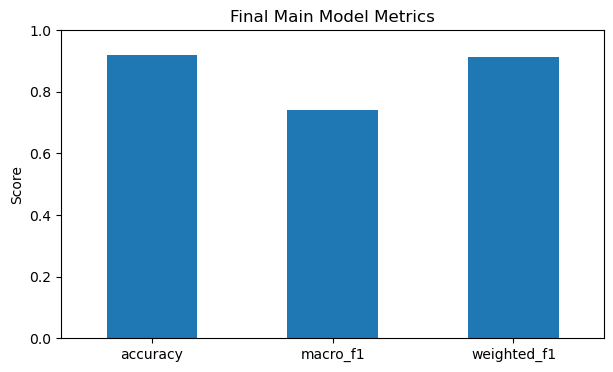

In [28]:

if results_df is not None and {"accuracy", "macro_f1", "weighted_f1"}.issubset(results_df.columns):
    plot_df = results_df[["accuracy", "macro_f1", "weighted_f1"]].iloc[[0]].T
    plot_df.columns = ["score"]
    plt.figure(figsize=(7, 4))
    plot_df["score"].plot(kind="bar")
    plt.title("Final Main Model Metrics")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.show()
else:
    print("Skipping final metric plot because the expected columns were not found.")


## 2) Load the combined credibility model

In [29]:

if not os.path.exists(COMBINED_MODEL_PATH):
    raise FileNotFoundError(f"Combined model not found: {COMBINED_MODEL_PATH}")

combined_bundle = joblib.load(COMBINED_MODEL_PATH)
scorer = combined_bundle["scorer"]

print("Loaded combined credibility model.")
print("Model type:", combined_bundle.get("model_type"))
print("Source sentiment bundle:", combined_bundle.get("source_sentiment_bundle"))
print("\nCredibility config:")
print(json.dumps(combined_bundle.get("config", {}), indent=2))


Loaded combined credibility model.
Model type: combined_sentiment_plus_credibility_scorer
Source sentiment bundle: dataset\best_single_review_model_v3.joblib

Credibility config:
{
  "duplicate_weight": 0.3,
  "generic_weight": 0.22,
  "mismatch_weight": 0.22,
  "unverified_weight": 0.08,
  "repetitive_weight": 0.1,
  "very_short_weight": 0.12,
  "medium_threshold": 0.3,
  "high_threshold": 0.6,
  "suspicious_threshold": 0.45
}


## 3) Load a processed test dataset

In [30]:

if not os.path.exists(TEST_DATASET_PATH):
    raise FileNotFoundError(f"Test dataset not found: {TEST_DATASET_PATH}")

df = pd.read_csv(TEST_DATASET_PATH, low_memory=False)
print("Input shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head(3))


Input shape: (50000, 9)
Columns: ['category', 'asin', 'overall', 'sentiment', 'verified', 'vote', 'unixReviewTime', 'text', 'clean_text']


,category,asin,overall,sentiment,verified,vote,unixReviewTime,text,clean_text
0,Arts Crafts and Sewing,B008SOZK2I,5.0,positive,True,NaN,1444176000,Very good deal. A very good buy for a jewlery maker(me),very good deal a very good buy for a jewlery maker me
1,Arts Crafts and Sewing,B0109326CM,5.0,positive,True,NaN,1484352000,Five Stars. good,five stars good
2,Arts Crafts and Sewing,B0012SG11Q,4.0,positive,True,NaN,1454371200,Four Stars. ok,four stars ok


## 4) Score the dataset with the combined model

In [31]:

required_cols = [CLEAN_TEXT_COL, CATEGORY_COL]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

scored_df = scorer.predict(df)

print("Scored shape:", scored_df.shape)
display(scored_df.head(5))

if SAVE_SCORED_OUTPUT:
    os.makedirs(os.path.dirname(SCORED_OUTPUT_CSV), exist_ok=True)
    scored_df.to_csv(SCORED_OUTPUT_CSV, index=False, encoding="utf-8")
    print(f"Saved scored dataset to: {SCORED_OUTPUT_CSV}")


Scored shape: (50000, 25)


,category,asin,overall,sentiment,verified,vote,unixReviewTime,text,clean_text,predicted_sentiment,...,very_short_text,generic_short_text,high_repetition,verified_bool,unverified_flag,rating_text_mismatch,low_credibility_score,low_credibility_label,suspicious_label,suspicious_reasons
0,Arts Crafts and Sewing,B008SOZK2I,5.0,positive,True,NaN,1444176000,Very good deal. A very good buy for a jewlery maker(me),very good deal a very good buy for a jewlery maker me,positive,...,False,False,True,True,False,False,0.10,low,not_suspicious,high_token_repetition
1,Arts Crafts and Sewing,B0109326CM,5.0,positive,True,NaN,1484352000,Five Stars. good,five stars good,positive,...,True,True,False,True,False,False,0.64,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; very_short_text
2,Arts Crafts and Sewing,B0012SG11Q,4.0,positive,True,NaN,1454371200,Four Stars. ok,four stars ok,positive,...,True,True,False,True,False,False,0.64,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; very_short_text
3,Arts Crafts and Sewing,B016KGF7UA,5.0,positive,False,NaN,1482364800,Five Stars. PERFECT !!!!!!!!!,five stars perfect,positive,...,True,True,False,False,True,False,0.72,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; not_verified_purchase; very_short_text
4,Arts Crafts and Sewing,B019I2EL96,5.0,positive,True,NaN,1465776000,Five Stars. Works well,five stars works well,positive,...,False,True,False,True,False,False,0.52,medium,suspicious,duplicate_or_repeated_text; very_short_generic_text


Saved scored dataset to: dataset\notebook_scored_reviews.csv


## 5) Accuracy and evaluation for the sentiment side on the test dataset

In [32]:

if TRUE_SENTIMENT_COL in scored_df.columns:
    valid = scored_df[TRUE_SENTIMENT_COL].notna()
    y_true = scored_df.loc[valid, TRUE_SENTIMENT_COL].astype(str)
    y_pred = scored_df.loc[valid, "predicted_sentiment"].astype(str)

    labels = sorted(set(y_true.unique()).union(set(y_pred.unique())))
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    sentiment_eval_summary = pd.DataFrame([{
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
        "row_count": int(valid.sum()),
    }])

    print("Sentiment evaluation on the current test dataset:")
    display(sentiment_eval_summary)

    sentiment_report = pd.DataFrame(
        classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    ).T.reset_index().rename(columns={"index": "label"})
    print("Classification report:")
    display(sentiment_report)

    sentiment_conf = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=labels),
        index=labels,
        columns=labels
    )
    print("Confusion matrix:")
    display(sentiment_conf)
else:
    print(f"Column '{TRUE_SENTIMENT_COL}' not found. Skipping sentiment accuracy evaluation.")


Sentiment evaluation on the current test dataset:


,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,row_count
0,0.9379,0.777659,0.719007,0.744645,0.932237,0.9379,0.934349,50000


Classification report:


,label,precision,recall,f1-score,support
0,negative,0.755368,0.708888,0.731390,2779.0000
1,neutral,0.613327,0.464789,0.528825,2911.0000
2,positive,0.964281,0.983345,0.973719,44310.0000
3,accuracy,0.937900,0.937900,0.937900,0.9379
4,macro avg,0.777659,0.719007,0.744645,50000.0000
5,weighted avg,0.932237,0.937900,0.934349,50000.0000


Confusion matrix:


,negative,neutral,positive
negative,1970,321,488
neutral,432,1353,1126
positive,206,532,43572


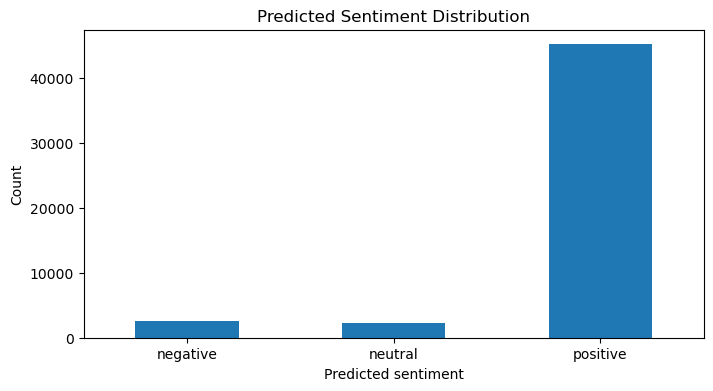

<Figure size 800x400 with 0 Axes>

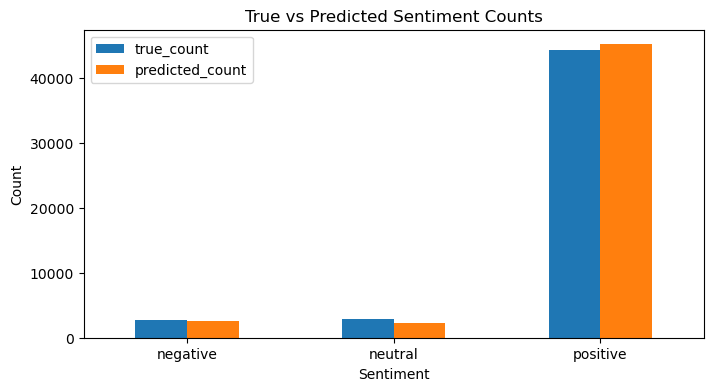

In [33]:

if TRUE_SENTIMENT_COL in scored_df.columns:
    pred_counts = scored_df["predicted_sentiment"].value_counts().sort_index()
    true_counts = scored_df[TRUE_SENTIMENT_COL].value_counts().sort_index()

    plt.figure(figsize=(8, 4))
    pred_counts.plot(kind="bar")
    plt.title("Predicted Sentiment Distribution")
    plt.xlabel("Predicted sentiment")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

    compare_df = pd.DataFrame({
        "true_count": true_counts,
        "predicted_count": pred_counts
    }).fillna(0)

    plt.figure(figsize=(8, 4))
    compare_df.plot(kind="bar", figsize=(8, 4))
    plt.title("True vs Predicted Sentiment Counts")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()


## 6) Summary for low-credibility / suspicious-review detection

In [34]:

summary_rows = []

overall_row = {
    "group_name": "ALL",
    "row_count": int(len(scored_df)),
    "suspicious_rate": round((scored_df["suspicious_label"] == "suspicious").mean(), 5),
    "high_risk_rate": round((scored_df["low_credibility_label"] == "high").mean(), 5),
    "avg_score": round(scored_df["low_credibility_score"].mean(), 5),
}
summary_rows.append(overall_row)

if CATEGORY_COL in scored_df.columns:
    for cat, part in scored_df.groupby(CATEGORY_COL):
        summary_rows.append({
            "group_name": cat,
            "row_count": int(len(part)),
            "suspicious_rate": round((part["suspicious_label"] == "suspicious").mean(), 5),
            "high_risk_rate": round((part["low_credibility_label"] == "high").mean(), 5),
            "avg_score": round(part["low_credibility_score"].mean(), 5),
        })

cred_summary_df = pd.DataFrame(summary_rows)
display(cred_summary_df)

if SAVE_SCORED_OUTPUT:
    cred_summary_df.to_csv(SUMMARY_OUTPUT_CSV, index=False, encoding="utf-8")
    print(f"Saved summary to: {SUMMARY_OUTPUT_CSV}")


,group_name,row_count,suspicious_rate,high_risk_rate,avg_score
0,ALL,50000,0.13974,0.05654,0.16131
1,Arts Crafts and Sewing,50000,0.13974,0.05654,0.16131


Saved summary to: dataset\notebook_scored_summary.csv


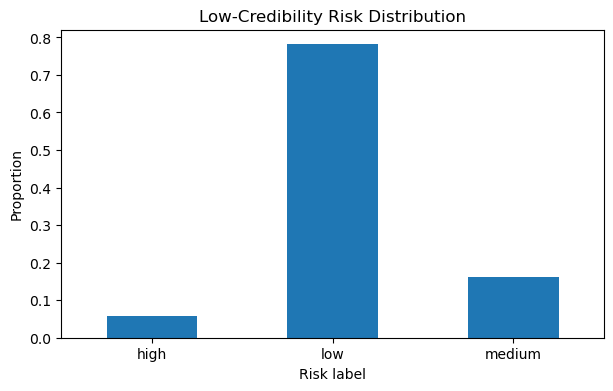

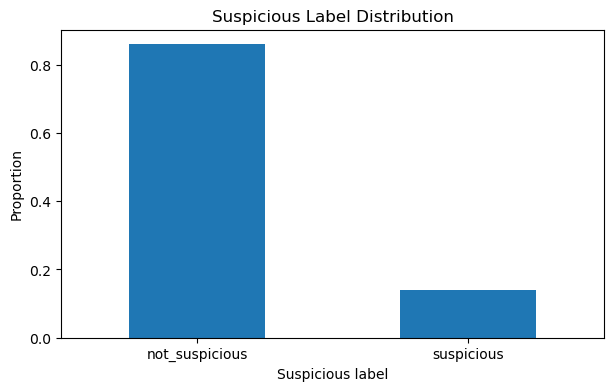

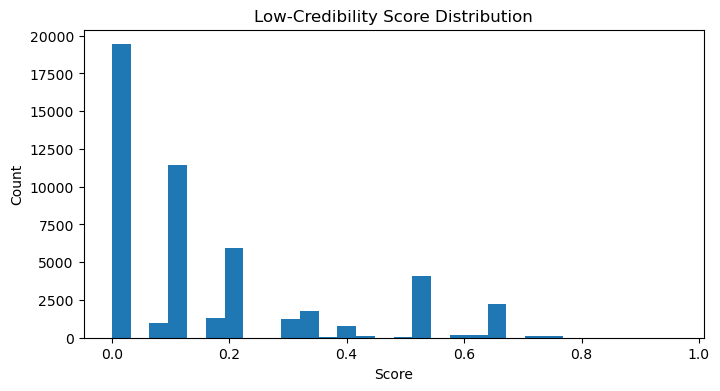

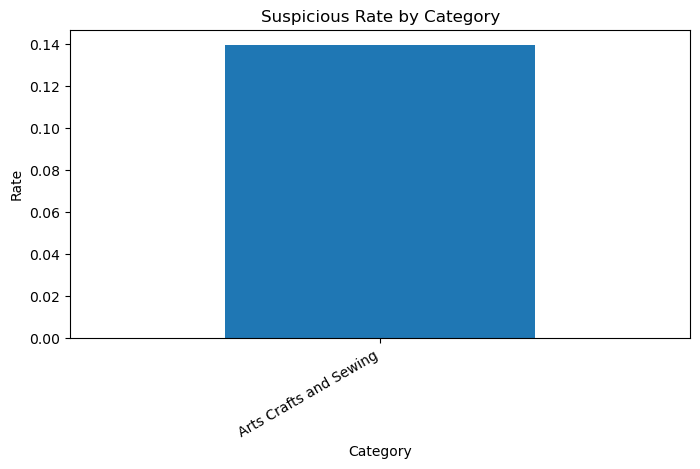

In [35]:

# Risk label distribution
risk_dist = scored_df["low_credibility_label"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(7, 4))
risk_dist.plot(kind="bar")
plt.title("Low-Credibility Risk Distribution")
plt.xlabel("Risk label")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

# Suspicious label distribution
sus_dist = scored_df["suspicious_label"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(7, 4))
sus_dist.plot(kind="bar")
plt.title("Suspicious Label Distribution")
plt.xlabel("Suspicious label")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

# Score histogram
plt.figure(figsize=(8, 4))
plt.hist(scored_df["low_credibility_score"], bins=30)
plt.title("Low-Credibility Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

# Category suspicious rate
if CATEGORY_COL in scored_df.columns:
    cat_rate = (
        scored_df.assign(is_suspicious=scored_df["suspicious_label"].eq("suspicious").astype(int))
        .groupby(CATEGORY_COL)["is_suspicious"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 4))
    cat_rate.plot(kind="bar")
    plt.title("Suspicious Rate by Category")
    plt.xlabel("Category")
    plt.ylabel("Rate")
    plt.xticks(rotation=30, ha="right")
    plt.show()


,count
none,19426
high_token_repetition,15432
very_short_generic_text,12789
duplicate_or_repeated_text,8698
not_verified_purchase,3127
very_short_text,2946
rating_text_mismatch,2252


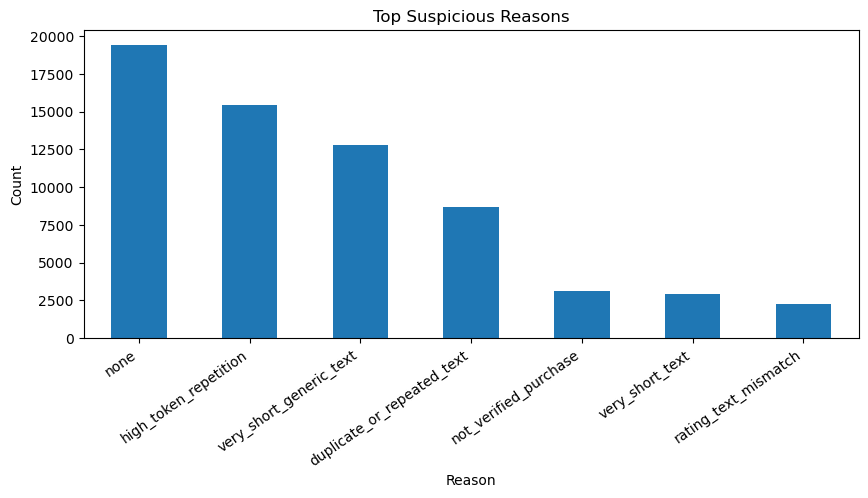

In [36]:

all_reasons = []
for value in scored_df["suspicious_reasons"].fillna(""):
    parts = [p.strip() for p in str(value).split(";") if p.strip()]
    all_reasons.extend(parts)

reason_counts = pd.Series(Counter(all_reasons)).sort_values(ascending=False)

if len(reason_counts) > 0:
    display(reason_counts.to_frame("count"))
    plt.figure(figsize=(10, 4))
    reason_counts.head(12).plot(kind="bar")
    plt.title("Top Suspicious Reasons")
    plt.xlabel("Reason")
    plt.ylabel("Count")
    plt.xticks(rotation=35, ha="right")
    plt.show()
else:
    print("No suspicious reasons found.")


## 7) Example reviews

In [37]:

example_cols = [
    CATEGORY_COL,
    TEXT_COL,
    "predicted_sentiment",
    "low_credibility_score",
    "low_credibility_label",
    "suspicious_label",
    "suspicious_reasons",
]
example_cols = [c for c in example_cols if c in scored_df.columns]

suspicious_examples = scored_df[scored_df["suspicious_label"] == "suspicious"].sample(
    n=min(NUM_SUSPICIOUS_EXAMPLES, (scored_df["suspicious_label"] == "suspicious").sum()),
    random_state=42,
)

not_suspicious_examples = scored_df[scored_df["suspicious_label"] == "not_suspicious"].sample(
    n=min(NUM_NOT_SUSPICIOUS_EXAMPLES, (scored_df["suspicious_label"] == "not_suspicious").sum()),
    random_state=42,
)

print("Suspicious examples:")
display(suspicious_examples[example_cols].reset_index(drop=True))

print("Not suspicious examples:")
display(not_suspicious_examples[example_cols].reset_index(drop=True))


Suspicious examples:


,category,text,predicted_sentiment,low_credibility_score,low_credibility_label,suspicious_label,suspicious_reasons
0,Arts Crafts and Sewing,Five Stars. very pretty,positive,0.52,medium,suspicious,duplicate_or_repeated_text; very_short_generic_text
1,Arts Crafts and Sewing,Five Stars. Love it,positive,0.52,medium,suspicious,duplicate_or_repeated_text; very_short_generic_text
2,Arts Crafts and Sewing,Five Stars. Just as expected!,positive,0.52,medium,suspicious,duplicate_or_repeated_text; very_short_generic_text
3,Arts Crafts and Sewing,Five Stars. Excellent,positive,0.64,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; very_short_text
4,Arts Crafts and Sewing,Five Stars. ok,positive,0.64,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; very_short_text
5,Arts Crafts and Sewing,Four Stars. nice,positive,0.64,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; very_short_text
6,Arts Crafts and Sewing,Five Stars. Just what I needed.,positive,0.52,medium,suspicious,duplicate_or_repeated_text; very_short_generic_text
7,Arts Crafts and Sewing,Five Stars. excelent,positive,0.64,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; very_short_text
8,Arts Crafts and Sewing,Five Stars. perfect,positive,0.64,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; very_short_text
9,Arts Crafts and Sewing,Five Stars. love them,positive,0.52,medium,suspicious,duplicate_or_repeated_text; very_short_generic_text


Not suspicious examples:


,category,text,predicted_sentiment,low_credibility_score,low_credibility_label,suspicious_label,suspicious_reasons
0,Arts Crafts and Sewing,"Added these to the screws on my hoops, adds .... Added these to the screws on my hoops, adds color to the hoops, works perfectly to reduce strain on finger joints with the right amount of torque needed to tighten the hoop.",positive,0.10,low,not_suspicious,high_token_repetition
1,Arts Crafts and Sewing,Five Stars. Very pretty color - cuts and weeds perfect!,positive,0.00,low,not_suspicious,none
2,Arts Crafts and Sewing,Four Stars. good price for brand,positive,0.22,low,not_suspicious,very_short_generic_text
3,Arts Crafts and Sewing,Easy. Great to help cut my soap loafs,positive,0.22,low,not_suspicious,very_short_generic_text
4,Arts Crafts and Sewing,Five Stars. cool tool works great.,positive,0.22,low,not_suspicious,very_short_generic_text
5,Arts Crafts and Sewing,product arrived on time & I love them! keeps my beads precisely where I want .... product arrived on time & I love them! keeps my beads precisely where I want them on my bracelets! Thanks!,positive,0.10,low,not_suspicious,high_token_repetition
6,Arts Crafts and Sewing,"best. I have the zero, one, and two in these mini brushes. These are the best you can buy and are wonderful. BUT they are for detail work or paintings where the person sits, they are not for huge paintings. I work with tiny details and honestly I could probably benefit from even smaller brush si...",positive,0.10,low,not_suspicious,high_token_repetition
7,Arts Crafts and Sewing,"Perfect fast transaction.. Fun, great patterns. Ultra fast delivery. Perfect transaction. Thank you!",positive,0.10,low,not_suspicious,high_token_repetition
8,Arts Crafts and Sewing,Five Stars. Easy to insert,positive,0.22,low,not_suspicious,very_short_generic_text
9,Arts Crafts and Sewing,"Four Stars. Some had defects, but otherwise these work well.",positive,0.00,low,not_suspicious,none


In [38]:

ranked_cols = [
    CATEGORY_COL,
    TEXT_COL,
    "predicted_sentiment",
    "low_credibility_score",
    "low_credibility_label",
    "suspicious_label",
    "suspicious_reasons",
]
ranked_cols = [c for c in ranked_cols if c in scored_df.columns]

top_high_risk = (
    scored_df.sort_values(["low_credibility_score"], ascending=False)
    .head(10)[ranked_cols]
    .reset_index(drop=True)
)

print("Top 10 highest-risk reviews:")
display(top_high_risk)


Top 10 highest-risk reviews:


,category,text,predicted_sentiment,low_credibility_score,low_credibility_label,suspicious_label,suspicious_reasons
0,Arts Crafts and Sewing,good. good,positive,0.96,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; rating_text_mismatch; high_token_repetition; very_short_text
1,Arts Crafts and Sewing,good. Good,positive,0.96,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; rating_text_mismatch; high_token_repetition; very_short_text
2,Arts Crafts and Sewing,Good. Good,positive,0.96,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; rating_text_mismatch; high_token_repetition; very_short_text
3,Arts Crafts and Sewing,good. good,positive,0.82,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; not_verified_purchase; high_token_repetition; very_short_text
4,Arts Crafts and Sewing,Excellent. Excellent,positive,0.74,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; high_token_repetition; very_short_text
5,Arts Crafts and Sewing,Awesome!. Awesome!,positive,0.74,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; high_token_repetition; very_short_text
6,Arts Crafts and Sewing,good. good,positive,0.74,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; high_token_repetition; very_short_text
7,Arts Crafts and Sewing,great. great,positive,0.74,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; high_token_repetition; very_short_text
8,Arts Crafts and Sewing,PERFECT. PERFECT,positive,0.74,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; high_token_repetition; very_short_text
9,Arts Crafts and Sewing,Great. Great,positive,0.74,high,suspicious,duplicate_or_repeated_text; very_short_generic_text; high_token_repetition; very_short_text


## 8) Optional save-outs for examples

In [39]:

EXAMPLE_DIR = r"dataset\notebook_examples"
os.makedirs(EXAMPLE_DIR, exist_ok=True)

suspicious_examples.to_csv(os.path.join(EXAMPLE_DIR, "suspicious_examples.csv"), index=False, encoding="utf-8")
not_suspicious_examples.to_csv(os.path.join(EXAMPLE_DIR, "not_suspicious_examples.csv"), index=False, encoding="utf-8")
top_high_risk.to_csv(os.path.join(EXAMPLE_DIR, "top_high_risk_examples.csv"), index=False, encoding="utf-8")

print(f"Saved example CSVs to: {EXAMPLE_DIR}")


Saved example CSVs to: dataset\notebook_examples
